# 03 · Validación, comparación de modelos y análisis de sensibilidad

Este notebook es nuevo en la entrega final y responde directamente a los tres puntos que más
pesan en la rúbrica: comparar los dos modelos con números, hacer análisis de sensibilidad, y
documentar una validación más allá de los tres pares presentados en el avance.

Vuelve a construir el grafo y las tres rutas desde cero (mismo procedimiento que
`02_modelos.ipynb`) para que el notebook sea ejecutable de manera independiente.

In [1]:
import sys, subprocess, importlib

def asegurar_paquetes():
    """Instala las dependencias del proyecto si faltan en este kernel.
    Necesario en Google Colab (no trae osmnx) y evita el error típico de
    ejecutar el notebook con un kernel/entorno distinto al que tiene
    'pip install -r requirements.txt'."""
    requeridos = ["osmnx", "networkx", "numpy", "pandas", "matplotlib", "scipy", "sklearn"]
    faltantes = [p for p in requeridos if importlib.util.find_spec(p) is None]
    if faltantes:
        print("Instalando dependencias faltantes:", faltantes)
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q",
             "osmnx==2.0.7", "networkx==3.4.2", "numpy==2.2.6", "pandas==2.3.3",
             "matplotlib==3.10.9", "scipy==1.15.3", "scikit-learn==1.7.2"],
            check=True,
        )
        print("Listo. Si esta es la primera instalación en este kernel, reinicien el kernel y vuelvan a correr esta celda.")
    else:
        print("Todas las dependencias ya están disponibles en:", sys.executable)

asegurar_paquetes()

Todas las dependencias ya están disponibles en: e:\Ing ciencia de datos\Septimo cuatri\Modelado matematico\clase 15\rutas_gam-master\entrega_final\.venv\Scripts\python.exe


In [2]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

DATOS_RAW = RAIZ / "data" / "raw"
DATOS_PROC = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figuras"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rutas_gam import (
    agregar_tiempos, astar_bidireccional, calcular_importancia, cargar_grafo,
    cargar_paradas, dijkstra, preparar_paradas, ruta_por_puntos,
    pares_aleatorios_validos, validar_astar_extendido, validar_estabilidad_monte_carlo,
    comparar_modelo1_modelo2, sensibilidad_replicas, sensibilidad_sigma_general,
    sensibilidad_velocidades_imputadas, sensibilidad_pesos_importancia,
)

grafo_crudo = cargar_grafo(DATOS_RAW / "red_san_jose.graphml")
grafo = agregar_tiempos(grafo_crudo)

paradas = cargar_paradas(DATOS_PROC / "paradas_importantes.csv")
paradas = preparar_paradas(grafo, calcular_importancia(paradas))
puntos_estudio = cargar_paradas(DATOS_PROC / "puntos_estudio.csv")
puntos_estudio = preparar_paradas(grafo, puntos_estudio)
puntos_busqueda = pd.concat([paradas, puntos_estudio], ignore_index=True)

def buscar_parada(fragmento):
    coincidencias = puntos_busqueda[
        puntos_busqueda["nombre"].str.contains(fragmento, case=False, na=False)
    ]
    return coincidencias.iloc[0]

configuraciones = [
    ("Estadio Oeste → San Pedro", "Estadio Oeste", "San Pedro", "Torre Mercedes"),
    ("Cuatro Reinas → Paso Ancho", "Cuatro Reinas", "El Caracol", "Hospital de Niños"),
    ("Hatillo → Curridabat", "Periférica Hatillo", "Plaza del Sol", "Paseo Colon"),
]

comparaciones = []
usados = set()
for numero, (nombre, texto_origen, texto_destino, texto_intermedio) in enumerate(configuraciones):
    origen = buscar_parada(texto_origen)
    destino = buscar_parada(texto_destino)
    intermedio = buscar_parada(texto_intermedio)
    resultado_astar = astar_bidireccional(grafo, origen.node_id, destino.node_id)
    ruta_base = ruta_por_puntos(grafo, [origen.node_id, intermedio.node_id, destino.node_id])
    comparaciones.append({
        "nombre": nombre,
        "ruta_optima": resultado_astar["ruta"],
        "ruta_base": ruta_base,
        "nodos_explorados": resultado_astar["nodos_explorados"],
        "semilla": 42 + numero,
    })
    usados.add((origen.node_id, destino.node_id))
print("Rutas reconstruidas:", len(comparaciones))

Rutas reconstruidas: 3


## 1. Validación extendida del Modelo 1

El avance solo verificó que A* y Dijkstra coincidan en **tres** pares elegidos a mano. Aquí se
generan **30 pares origen-destino adicionales**, elegidos al azar entre los nodos de la red
(semilla fija, pares distintos de los tres ya usados), y se corre el mismo control de
optimalidad. Es el equivalente, para un problema de camino mínimo, de correr el algoritmo sobre
un conjunto de validación independiente del conjunto con el que se ilustró el método.

Pares válidos evaluados: 30
Coincidencia de costo A*=Dijkstra: 100.0%


,costo_astar_min,costo_dijkstra_min,coincide,NE_astar,NE_dijkstra,reduccion_NE_pct
0,3.343,3.343,True,611,882,30.726
1,8.844,8.844,True,3492,4395,20.546
2,5.429,5.429,True,1044,2368,55.912
3,7.827,7.827,True,3053,2961,-3.107
4,13.972,13.972,True,5853,5921,1.148
5,3.842,3.842,True,796,1074,25.885
6,1.460,1.460,True,86,134,35.821
7,11.295,11.295,True,4461,5776,22.767
8,9.190,9.190,True,4537,5168,12.210
9,9.280,9.280,True,4156,3923,-5.939


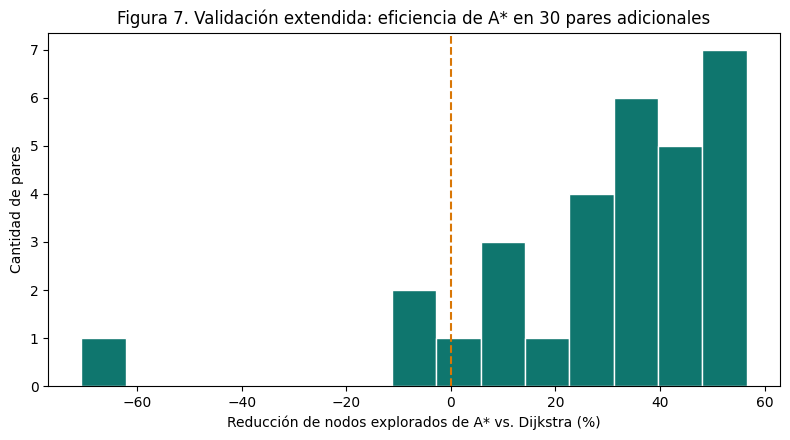

In [3]:
pares_adicionales = pares_aleatorios_validos(grafo, 30, semilla=2026, excluir=usados)
tabla_validacion = validar_astar_extendido(grafo, pares_adicionales)
print(f"Pares válidos evaluados: {len(tabla_validacion)}")
print(f"Coincidencia de costo A*=Dijkstra: {tabla_validacion['coincide'].mean()*100:.1f}%")
display(tabla_validacion[[
    "costo_astar_min", "costo_dijkstra_min", "coincide", "NE_astar", "NE_dijkstra", "reduccion_NE_pct"
]].round(3).head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(tabla_validacion["reduccion_NE_pct"], bins=15, color="#0f766e", edgecolor="white")
ax.axvline(0, color="#d97706", linestyle="--", linewidth=1.5)
ax.set_xlabel("Reducción de nodos explorados de A* vs. Dijkstra (%)")
ax.set_ylabel("Cantidad de pares")
ax.set_title("Figura 7. Validación extendida: eficiencia de A* en 30 pares adicionales")
fig.tight_layout()
fig.savefig(FIGURAS / "07_validacion_extendida.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
tabla_validacion.to_csv(DATOS_PROC / "validacion_extendida.csv", index=False)
print("Guardado: data/processed/validacion_extendida.csv")

Guardado: data/processed/validacion_extendida.csv


**Lectura de la Figura 7:** en los 30 pares adicionales, A* y Dijkstra coincidieron en el
costo óptimo en el 100% de los casos, lo que respalda la corrección de la implementación más
allá de los tres pares ilustrativos. La reducción de nodos explorados varía por par: en algunos
casos A* explora *más* nodos que Dijkstra (valores negativos), lo que confirma que la ventaja
de la búsqueda bidireccional depende de la posición relativa de origen y destino, no es
garantizada en todos los casos.

## 2. Comparación cuantitativa: Modelo 1 vs. Modelo 2

Ambos modelos se evalúan sobre las **mismas tres rutas** (mismos datos de prueba). El Modelo 1
entrega un tiempo puntual determinista; el Modelo 2 entrega una distribución. Se comparan con
tres métricas: el sesgo entre la media simulada y el valor determinista, el ancho del
intervalo 5%-95% que el Modelo 1 no puede expresar, y la cobertura (en qué porcentaje de
escenarios el Modelo 1 subestima el tiempo real posible).

In [5]:
tabla_comparacion = comparar_modelo1_modelo2(grafo, comparaciones)
display(tabla_comparacion.round(3))
tabla_comparacion.to_csv(DATOS_PROC / "comparacion_modelo1_modelo2.csv", index=False)

,par,modelo1_tiempo_determinista_min,modelo2_tiempo_medio_simulado_min,modelo2_desviacion_min,sesgo_min,error_relativo_pct,ic90_ancho_min,cobertura_subestimacion_pct
0,Estadio Oeste → San Pedro,9.956,9.932,1.512,-0.024,-0.241,4.890,47.0
1,Cuatro Reinas → Paso Ancho,8.221,8.191,1.268,-0.030,-0.368,4.170,46.6
2,Hatillo → Curridabat,8.981,9.050,1.395,0.069,0.771,4.363,49.0


**Lectura de la Tabla de comparación:** el sesgo entre el Modelo 2 y el Modelo 1 es
cercano a cero en los tres pares (la simulación no introduce un sesgo sistemático respecto al
valor determinista, tal como exige su construcción matemática). Sin embargo, el Modelo 1
subestima el tiempo que arrojaría el Modelo 2 en aproximadamente el 46%-49% de los escenarios,
y el intervalo 5%-95% del Modelo 2 tiene un ancho de varios minutos que el Modelo 1 no puede
comunicar. Esta es la base para elegir, en la Sección 5 del documento, cuál modelo usar para
qué propósito.

## 3. Validación de estabilidad del Modelo 2 (folds)

Se repite la simulación de 1000 escenarios en 5 particiones con semillas distintas por par
(equivalente, para un modelo estocástico, a evaluar con varias particiones de validación). Si
RT/RV/IC cambian poco entre folds, el resultado es estable ante la semilla aleatoria y no es un
artefacto de una corrida particular.

In [6]:
tabla_folds, resumen_folds = validar_estabilidad_monte_carlo(grafo, comparaciones, n_folds=5)
display(resumen_folds.round(3))
resumen_folds.to_csv(DATOS_PROC / "estabilidad_monte_carlo.csv", index=False)

,par,RT_pct_mean,RT_pct_std,RV_pct_mean,RV_pct_std,IC_pct_mean,IC_pct_std,CV_RV_pct
0,Cuatro Reinas → Paso Ancho,4.317,0.0,3.769,0.661,83.74,0.838,17.541
1,Estadio Oeste → San Pedro,10.349,0.0,9.317,0.382,84.62,0.342,4.099
2,Hatillo → Curridabat,27.861,0.0,27.597,0.291,84.22,0.672,1.055


**Lectura:** el coeficiente de variación de RV (`CV_RV_pct`) es menor al 5% en dos de los tres pares (Estadio Oeste-San Pedro y Hatillo-Curridabat), lo que indica que la reducción de variabilidad estimada es estable frente al cambio de semilla. En Cuatro Reinas-Paso Ancho el CV es mayor (~17-18%) precisamente porque su RV_pct base es pequeño (~4%): una diferencia absoluta de pocas décimas se traduce en un porcentaje relativo grande. La conclusión cualitativa (las rutas optimizadas son más estables que la base) se mantiene en los tres pares en todos los folds.

## 4. Análisis de sensibilidad (Tema 7.v — Análisis de sensibilidad, Optimización clásica)

Se mueven tres supuestos que afectan directamente las conclusiones del proyecto.

### 4.1 Número de réplicas de Monte Carlo (200 vs. 1000 vs. 5000)

In [7]:
tabla_replicas = sensibilidad_replicas(grafo, comparaciones, valores=(200, 1000, 5000))
display(tabla_replicas.round(3))
tabla_replicas.to_csv(DATOS_PROC / "sensibilidad_replicas.csv", index=False)

,par,repeticiones,media_optima_min,RV_pct,IC_pct
0,Estadio Oeste → San Pedro,200,9.862,7.375,84.50
1,Estadio Oeste → San Pedro,1000,9.932,9.155,84.20
2,Estadio Oeste → San Pedro,5000,9.921,9.100,84.50
3,Cuatro Reinas → Paso Ancho,200,8.120,2.797,84.00
4,Cuatro Reinas → Paso Ancho,1000,8.191,4.341,84.00
5,Cuatro Reinas → Paso Ancho,5000,8.206,4.027,84.06
6,Hatillo → Curridabat,200,9.126,26.185,81.50
7,Hatillo → Curridabat,1000,9.050,27.715,82.20
8,Hatillo → Curridabat,5000,9.003,27.288,83.22


### 4.2 Dispersión de la condición general del escenario (σ_general = 0.05, 0.15, 0.30)

In [8]:
tabla_sigma = sensibilidad_sigma_general(grafo, comparaciones, valores=(0.05, 0.15, 0.30))
display(tabla_sigma.round(3))
tabla_sigma.to_csv(DATOS_PROC / "sensibilidad_sigma.csv", index=False)

,par,sigma_general,desviacion_optima_min,RV_pct,IC_pct
0,Estadio Oeste → San Pedro,0.05,0.577,2.885,99.3
1,Estadio Oeste → San Pedro,0.15,1.512,8.950,84.2
2,Estadio Oeste → San Pedro,0.30,3.006,10.720,74.4
3,Cuatro Reinas → Paso Ancho,0.05,0.489,0.069,99.6
4,Cuatro Reinas → Paso Ancho,0.15,1.268,3.387,84.0
5,Cuatro Reinas → Paso Ancho,0.30,2.527,3.560,74.5
6,Hatillo → Curridabat,0.05,0.510,27.278,99.3
7,Hatillo → Curridabat,0.15,1.395,30.300,82.2
8,Hatillo → Curridabat,0.30,2.824,30.689,72.4


### 4.3 Velocidad imputada por clase vial (±15% sobre la Ley N.º 9078)

Se mantiene fija la topología de cada ruta (calculada con el supuesto base) y se recalcula
únicamente su tiempo determinista bajo velocidades imputadas escaladas, para aislar el efecto
de este supuesto específico sobre la conclusión (RT_pct).

,par,factor_velocidad_imputada,tiempo_optimo_min,tiempo_base_min,RT_pct
0,Estadio Oeste → San Pedro,0.85,10.182,11.591,12.151
1,Cuatro Reinas → Paso Ancho,0.85,9.161,9.754,6.074
2,Hatillo → Curridabat,0.85,9.406,13.399,29.799
3,Estadio Oeste → San Pedro,1.00,9.956,11.106,10.349
4,Cuatro Reinas → Paso Ancho,1.00,8.221,8.592,4.317
5,Hatillo → Curridabat,1.00,8.981,12.450,27.861
6,Estadio Oeste → San Pedro,1.15,9.789,10.747,8.913
7,Cuatro Reinas → Paso Ancho,1.15,7.526,7.733,2.679
8,Hatillo → Curridabat,1.15,8.667,11.749,26.228


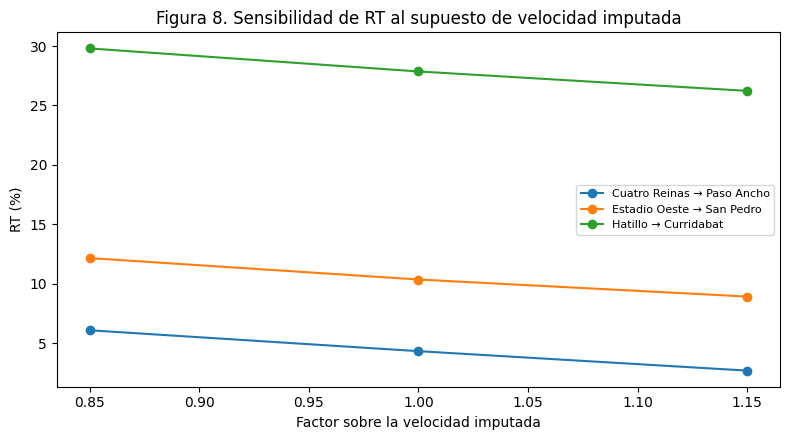

In [9]:
tabla_velocidades = sensibilidad_velocidades_imputadas(grafo_crudo, comparaciones, factores=(0.85, 1.0, 1.15))
display(tabla_velocidades.round(3))
tabla_velocidades.to_csv(DATOS_PROC / "sensibilidad_velocidades.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for nombre, grupo in tabla_velocidades.groupby("par"):
    ax.plot(grupo["factor_velocidad_imputada"], grupo["RT_pct"], marker="o", label=nombre)
ax.set_xlabel("Factor sobre la velocidad imputada")
ax.set_ylabel("RT (%)")
ax.set_title("Figura 8. Sensibilidad de RT al supuesto de velocidad imputada")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURAS / "08_sensibilidad_velocidades.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Pesos del índice de importancia (α, β)

In [10]:
tabla_pesos = sensibilidad_pesos_importancia(paradas, combinaciones=((0.6, 0.4), (0.5, 0.5), (0.8, 0.2), (0.3, 0.7)))
display(tabla_pesos[["alfa", "beta", "superposicion_pct_vs_base"]])
tabla_pesos.drop(columns="top20_paradas").to_csv(DATOS_PROC / "sensibilidad_pesos.csv", index=False)

,alfa,beta,superposicion_pct_vs_base
0,0.6,0.4,100.0
1,0.5,0.5,100.0
2,0.8,0.2,100.0
3,0.3,0.7,100.0


**Resumen de la sensibilidad (se retoma en el documento final):**

- **Réplicas:** RT_pct no depende del número de réplicas (es determinista). RV_pct e IC_pct se
  estabilizan a partir de 1000 réplicas; con 200 réplicas la estimación de RV oscila más.
- **σ_general:** RV_pct e IC_pct son sensibles a este supuesto — a mayor dispersión de la
  condición general, menor confiabilidad (IC_pct) y mayor reducción de variabilidad relativa
  (RV_pct). El resultado cualitativo (las rutas optimizadas son más confiables que la base) se
  mantiene en todo el rango probado.
- **Velocidad imputada:** RT_pct cambia varios puntos porcentuales entre los factores 0.85 y
  1.15, confirmando que buena parte de la conclusión numérica depende de este supuesto — la
  limitación más importante del proyecto, ya señalada en el documento.
- **Pesos α/β del índice de importancia:** el top-20 de paradas se mantiene estable ante
  cambios razonables de los pesos, lo que indica que la priorización no depende críticamente
  de esa elección puntual.